# 3. Projekat iz predmeta **Mašinsko učenje**
**Dataset:**  
[50k Bug Dataset](https://www.kaggle.com/datasets/mirzayasirabdullah07/50k-bug-dataset)

## Setup i učitavanje
### Import biblioteka i setovanje konstantni

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping


### Učitavanje podataka i pregled strukture

In [98]:
dataset = pd.read_csv('data.csv', encoding='latin-1')

dataset.info()
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bug_id          50000 non-null  object 
 1   title           50000 non-null  object 
 2   description     50000 non-null  object 
 3   error_code      43812 non-null  float64
 4   bug_category    50000 non-null  object 
 5   bug_domain      50000 non-null  object 
 6   tech_stack      50000 non-null  object 
 7   severity        50000 non-null  object 
 8   environment     50000 non-null  object 
 9   developer_role  50000 non-null  object 
 10  root_cause      50000 non-null  object 
 11  suggested_fix   50000 non-null  object 
 12  explanation     50000 non-null  object 
 13  created_at      50000 non-null  object 
dtypes: float64(1), object(13)
memory usage: 5.3+ MB


,error_code
count,43812.000000
mean,445.129394
std,49.398821
min,400.000000
25%,401.000000
50%,404.000000
75%,502.000000
max,503.000000


In [99]:
dataset.head()

,bug_id,title,description,error_code,bug_category,bug_domain,tech_stack,severity,environment,developer_role,root_cause,suggested_fix,explanation,created_at
0,BUG_000001,API Bug detected in system,This issue relates to a api bug occurring in the applica...,403.0,API Bug,Mobile,Spring Boot,High,Development,Full-Stack Developer,Misconfiguration or logic issue related to api bug,Review and fix the api bug according to best practices,This bug requires a full-stack developer due to its nature.,2025-04-07
1,BUG_000002,Memory Leak detected in system,This issue relates to a memory leak occurring in the app...,500.0,Memory Leak,Data,GCP,Medium,Production,Backend Developer,Misconfiguration or logic issue related to memory leak,Review and fix the memory leak according to best practices,This bug requires a backend developer due to its nature.,2025-07-04
2,BUG_000003,Cloud Configuration Bug detected in system,This issue relates to a cloud configuration bug occurrin...,404.0,Cloud Configuration Bug,DevOps,Django,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to cloud configu...,Review and fix the cloud configuration bug according to ...,This bug requires a mobile developer due to its nature.,2025-05-02
3,BUG_000004,Authentication Bug detected in system,This issue relates to a authentication bug occurring in ...,404.0,Authentication Bug,Backend Systems,Flask,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to authenticatio...,Review and fix the authentication bug according to best ...,This bug requires a mobile developer due to its nature.,2025-07-03
4,BUG_000005,Logging Bug detected in system,This issue relates to a logging bug occurring in the app...,503.0,Logging Bug,Mobile,Flask,High,Staging,Backend Developer,Misconfiguration or logic issue related to logging bug,Review and fix the logging bug according to best practices,This bug requires a backend developer due to its nature.,2025-09-09


## Preprocesiranje podataka

### Uklanjanje duplikata

In [100]:
broj_duplikata = dataset.duplicated().sum()
print(f'Broj duplikata: {broj_duplikata}')

Broj duplikata: 0


### Analiza podataka

#### Analiza nedostajućih vrednosti

In [101]:
dataset.isnull().sum()

bug_id               0
title                0
description          0
error_code        6188
bug_category         0
bug_domain           0
tech_stack           0
severity             0
environment          0
developer_role       0
root_cause           0
suggested_fix        0
explanation          0
created_at           0
dtype: int64

### Uklanjanje nepotrebnih kolona

Izbacujemo sledeće kolone:
- <i>bug_id</i> — identifikator, nema prediktivnu vrednost
- <i>created_at</i> — datum nije relevantan za severity
- <i>suggested_fix</i> — direktno izvedena iz <i>bug_category</i>, ne donosi novu informaciju
- <i>title</i> i <i>description</i> — **100% redundantne** sa <i>bug_category</i> (template tekst, 16 jedinstvenih vrednosti na 50k redova)
- <i>root_cause</i> i <i>explanation</i> — takođe template kolone izvedene iz <i>bug_category</i>

In [102]:
redundant_cols = ['bug_category', 'title', 'description', 'root_cause', 'suggested_fix', 'explanation']
demo = dataset[redundant_cols].drop_duplicates().sort_values('bug_category').head(1)

pd.set_option('display.max_colwidth', 60)
demo.T.rename(columns={demo.index[0]: 'Primer vrednosti'})

,Primer vrednosti
bug_category,API Bug
title,API Bug detected in system
description,This issue relates to a api bug occurring in the applica...
root_cause,Misconfiguration or logic issue related to api bug
suggested_fix,Review and fix the api bug according to best practices
explanation,This bug requires a full-stack developer due to its nature.


In [103]:
drop_cols = ['bug_id', 'created_at', 'suggested_fix', 'title', 'description', 'explanation', 'root_cause']
dataset = dataset.drop(columns=drop_cols)

print('Preostale kolone:', dataset.columns.tolist())
print('Dimenzije dataseta:', dataset.shape)

Preostale kolone: ['error_code', 'bug_category', 'bug_domain', 'tech_stack', 'severity', 'environment', 'developer_role']
Dimenzije dataseta: (50000, 7)


### Obrada kolone: <b>error_code</b>

Kolona <i>error_code</i> ima ~6.188 nedostajućih vrednosti (~12.4%). Umesto imputacije modom, tretiramo ih kao posebnu kategoriju <i>unknown</i> — jer odsustvo error koda može samo po sebi biti informativno.

In [104]:
dataset['error_code'] = dataset['error_code'].fillna(0).astype(str)
dataset['error_code'] = dataset['error_code'].replace('0.0', 'unknown')
dataset['error_code'] = dataset['error_code'].apply(lambda x: x.replace('.0', '') if x != 'unknown' else x)

print('Vrednosti error_code:')
print(dataset['error_code'].value_counts())

Vrednosti error_code:
error_code
503        6421
404        6335
401        6279
502        6278
500        6254
unknown    6188
403        6157
400        6088
Name: count, dtype: int64


## EDA

#### Distribucija targeta - <i>severity</i>

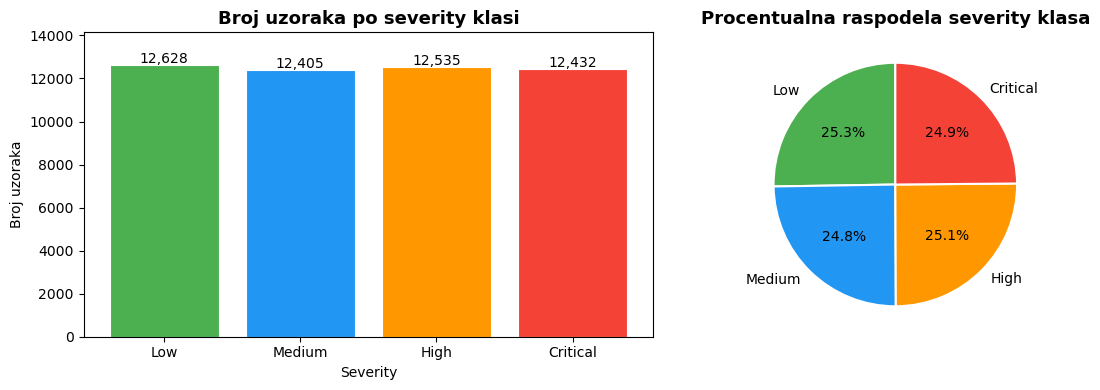

Distribucija klasa:
  Low: 12,628 (25.3%)
  Medium: 12,405 (24.8%)
  High: 12,535 (25.1%)
  Critical: 12,432 (24.9%)


In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

severity_order = ['Low', 'Medium', 'High', 'Critical']
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
counts = dataset['severity'].value_counts().reindex(severity_order)

# Bar chart
axes[0].bar(severity_order, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Broj uzoraka po severity klasi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Broj uzoraka')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)
axes[0].set_ylim(0, counts.max() * 1.12)

# Pie chart
axes[1].pie(counts.values, labels=severity_order, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Procentualna raspodela severity klasa', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('Distribucija klasa:')
for cls in severity_order:
    n = counts[cls]
    print(f'  {cls}: {n:,} ({n/len(dataset)*100:.1f}%)')

#### Severity po <i>bug_category</i>

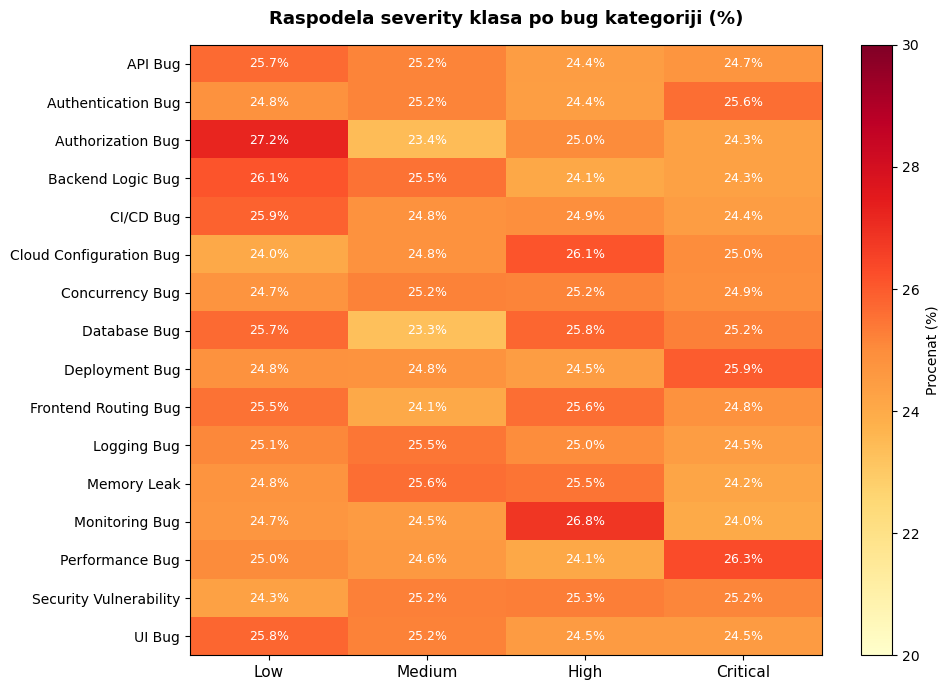

In [106]:
severity_order = ['Low', 'Medium', 'High', 'Critical']

pivot = dataset.groupby(['bug_category', 'severity']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=severity_order)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(pivot_pct.values, cmap='YlOrRd', aspect='auto', vmin=20, vmax=30)

ax.set_xticks(range(len(severity_order)))
ax.set_xticklabels(severity_order, fontsize=11)
ax.set_yticks(range(len(pivot_pct)))
ax.set_yticklabels(pivot_pct.index, fontsize=10)
ax.set_title('Raspodela severity klasa po bug kategoriji (%)', fontsize=13, fontweight='bold', pad=15)

for i in range(len(pivot_pct)):
    for j in range(len(severity_order)):
        val = pivot_pct.values[i, j]
        color = 'white' if val > 22 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax, label='Procenat (%)')
plt.tight_layout()
plt.show()

#### Korelaciona matrica feature-a

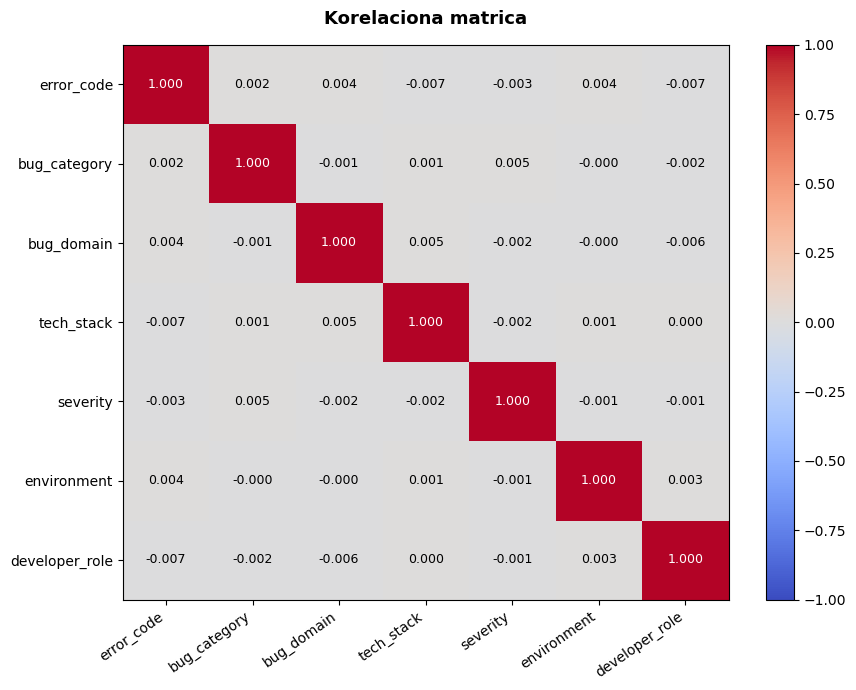

In [107]:
from sklearn.preprocessing import LabelEncoder

df_corr = dataset.copy()
severity_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df_corr['severity'] = df_corr['severity'].map(severity_map)

for col in ['bug_category', 'bug_domain', 'tech_stack', 'environment', 'developer_role', 'error_code']:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

labels = corr.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('Korelaciona matrica', fontsize=13, fontweight='bold', pad=15)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

#### Severity po <i>environment</i>

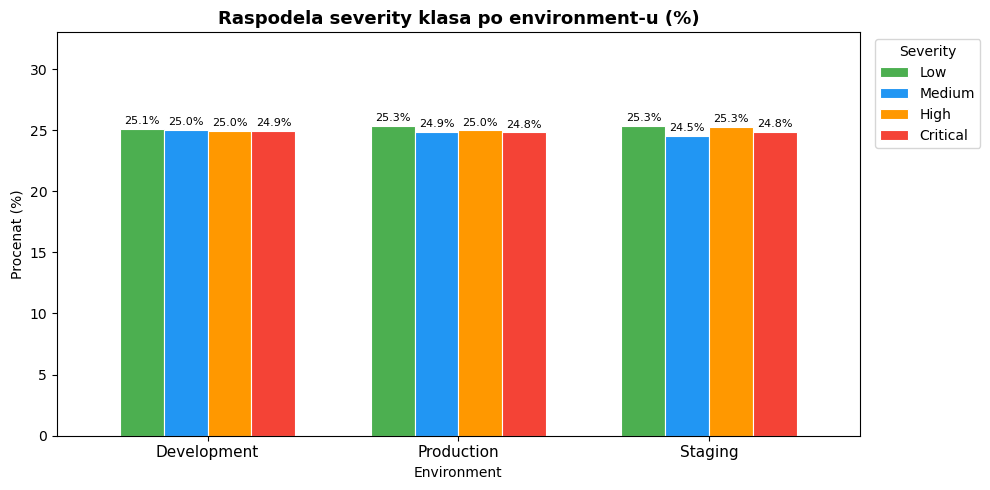

In [108]:
severity_order = ['Low', 'Medium', 'High', 'Critical']
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']

pivot = dataset.groupby(['environment', 'severity']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=severity_order)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

ax = pivot_pct.plot(kind='bar', figsize=(10, 5), color=colors,
                    edgecolor='white', linewidth=0.8, width=0.7)
ax.set_title('Raspodela severity klasa po environment-u (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Environment')
ax.set_ylabel('Procenat (%)')
ax.set_xticklabels(pivot_pct.index, rotation=0, fontsize=11)
ax.legend(title='Severity', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 33)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

#### <i>error_code</i> distribucija po severity

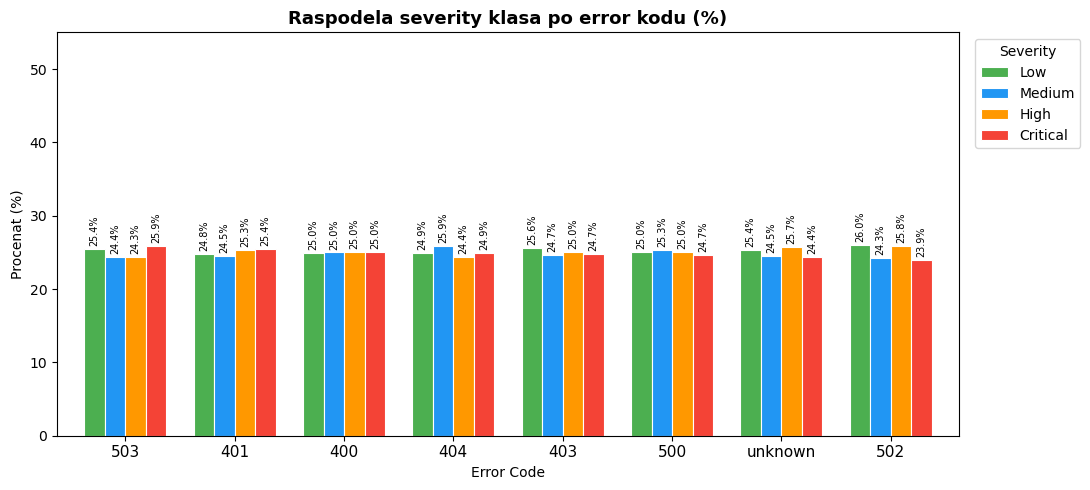

In [109]:
severity_order = ['Low', 'Medium', 'High', 'Critical']
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']

pivot = dataset.groupby(['error_code', 'severity']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=severity_order)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.sort_values('Critical', ascending=False)

ax = pivot_pct.plot(kind='bar', figsize=(11, 5), color=colors,
                    edgecolor='white', linewidth=0.8, width=0.75)
ax.set_title('Raspodela severity klasa po error kodu (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Error Code')
ax.set_ylabel('Procenat (%)')
ax.set_xticklabels(pivot_pct.index, rotation=0, fontsize=11)
ax.legend(title='Severity', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 55)

for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h > 1.5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.4,
                f'{h:.1f}%',
                ha='center', va='bottom',
                fontsize=7, rotation=90
            )

plt.tight_layout()
plt.show()

### Enkodiranje kategoričkih promenljivih

Sve kategoričke kolone konvertujemo u numeričke vrednosti:

- Za input features koristi se One-Hot encoding: <i>bug_category</i>, <i>bug_domain</i>, <i>tech_stack</i>, <i>environment</i>, <i>developer_role</i>, <i>error_code</i>
- Za target se koristi Label encoding: <i>severity</i> 

In [110]:
from sklearn.preprocessing import LabelEncoder

severity_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
dataset['severity'] = dataset['severity'].map(severity_order)

print('Mapiranje severity:')
for k, v in severity_order.items():
    print(f'  {v} -> {k}')
print()

nominal_cols = ['bug_category', 'bug_domain', 'tech_stack', 'environment', 'developer_role', 'error_code']
dataset = pd.get_dummies(dataset, columns=nominal_cols)

print('Dimenzije nakon One-Hot Encodinga:', dataset.shape)
print('Broj OHE kolona:', dataset.shape[1] - 1, '(bez targeta)')

Mapiranje severity:
  0 -> Low
  1 -> Medium
  2 -> High
  3 -> Critical

Dimenzije nakon One-Hot Encodinga: (50000, 59)
Broj OHE kolona: 58 (bez targeta)


In [111]:
print('Dimenzije:', dataset.shape)
print('\nTipovi podataka:')
print(dataset.dtypes.value_counts())
print('\nPreostale nedostajuće vrednosti:')
print(dataset.isnull().sum().sum())
print('\nDistribucija targeta (severity):')
print(dataset['severity'].value_counts().sort_index())
dataset.head()

Dimenzije: (50000, 59)

Tipovi podataka:
bool     58
int64     1
Name: count, dtype: int64

Preostale nedostajuće vrednosti:
0

Distribucija targeta (severity):
severity
0    12628
1    12405
2    12535
3    12432
Name: count, dtype: int64


,severity,bug_category_API Bug,bug_category_Authentication Bug,bug_category_Authorization Bug,bug_category_Backend Logic Bug,bug_category_CI/CD Bug,bug_category_Cloud Configuration Bug,bug_category_Concurrency Bug,bug_category_Database Bug,bug_category_Deployment Bug,...,developer_role_QA Engineer,developer_role_Security Engineer,error_code_400,error_code_401,error_code_403,error_code_404,error_code_500,error_code_502,error_code_503,error_code_unknown
0,2,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,1,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,1,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,2,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
